In [1]:
def read_csv(filepath, delimiter=","):
    data = []
    try:
        with open(filepath, "r", encoding="utf-8") as file:
            for line in file:
                # Strip newline and split by delimiter
                row = line.strip().split(delimiter)
                data.append(row)
        return data
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
        return []
    except Exception as e:
        print(f"Error reading file: {e}")
        return []
    

filename = r"C:\Users\dangq\OneDrive\Máy tính\USTH\M1\DeepLearing\SonTG\dl2026\lab3\data\loan2.csv"  # Replace with your CSV file path
csv_data = read_csv(filename)

csv_data

[['Experience', ' Salary', ' Loan'],
 ['3', '4', '1'],
 ['2.5', '4', '1'],
 ['1', '4', '0'],
 ['2.5', '5', '1'],
 ['2', '5', '1'],
 ['1.5', '5', '0'],
 ['0.5', '5', '0'],
 ['1.75', '6', '1'],
 ['0.25', '6', '0'],
 ['1', '7', '1'],
 ['0.25', '7', '0'],
 ['0.20', '7', '0'],
 ['0.15', '7', '0'],
 ['2', '8', '1'],
 ['1', '8', '0'],
 ['0.15', '8', '0'],
 ['0.10', '8', '0'],
 ['0.5', '9', '1'],
 ['1', '10', '1']]

In [2]:
def convert_to_float(data):
    for i in range(len(data)):
        if i == 0:
            continue  # Skip the header row
        for j in range(len(data[i])):
            data[i][j] = float(data[i][j])
    return data

csv_data = convert_to_float(csv_data)
csv_data

[['Experience', ' Salary', ' Loan'],
 [3.0, 4.0, 1.0],
 [2.5, 4.0, 1.0],
 [1.0, 4.0, 0.0],
 [2.5, 5.0, 1.0],
 [2.0, 5.0, 1.0],
 [1.5, 5.0, 0.0],
 [0.5, 5.0, 0.0],
 [1.75, 6.0, 1.0],
 [0.25, 6.0, 0.0],
 [1.0, 7.0, 1.0],
 [0.25, 7.0, 0.0],
 [0.2, 7.0, 0.0],
 [0.15, 7.0, 0.0],
 [2.0, 8.0, 1.0],
 [1.0, 8.0, 0.0],
 [0.15, 8.0, 0.0],
 [0.1, 8.0, 0.0],
 [0.5, 9.0, 1.0],
 [1.0, 10.0, 1.0]]

# Logistic Regression 

In [ ]:
import math
def ln(y):
    return math.log(y)

def sigmoid(x):
    # Clip x to a safe range to prevent math.exp() OverflowError ( CHAT FOR THAT ERROR )
    x = max(-500, min(x, 500))
    return 1 / (1 + math.exp(-x))

def Loss(w0, w1, w2, x, y):
    n = len(x)
    total_loss = 0
    
    for i in range(n):
        z_i = w1 * x[i][0] + w2 * x[i][1] + w0
        
        # Calculate the loss for the i-th data point
        total_loss = total_loss + (y[i] * z_i) - math.log(1 + math.exp(z_i))
        
    return (-1 / n) * total_loss

# def Loss_extras(w0, w1, w2, x, y):
#     n = len(x)
#     total_loss = 0
#     epsilon = 1e-15 # Prevents log(0) crashes
    
#     for i in range(n):
#         # Calculate linear combination
#         z_i = w1 * x[i][0] + w2 * x[i][1] + w0
        
#         # Clip z_i so it stays strictly between 0 and 1 for the log function
#         z_i = max(epsilon, min(1 - epsilon, z_i))
        
#         # Apply Equation 24 directly
#         term1 = y[i] * math.log(z_i)
#         term2 = (1 - y[i]) * math.log(1 - z_i)
        
#         total_loss += -(term1 + term2)
        
#     return (1 / n) * total_loss

def dLoss_dw0(w0, w1, w2, x, y):
    n = len(x)
    total_w0 = 0
    for i in range(n):
        z_i = w1 * x[i][0] + w2 * x[i][1] + w0

        total_w0 = total_w0 + (1 - y[i] - sigmoid(-z_i))

    return (1 / n) * total_w0

def dLoss_dw1(w0, w1, w2, x, y):
    n = len(x)
    total_w1 = 0
    for i in range(n):
        z_i = w1 * x[i][0] + w2 * x[i][1] + w0
        total_w1 = total_w1 + (-y[i]*x[i][0] + x[i][0]*(1-sigmoid(-z_i)))
    
    return (1/n) * total_w1 

# def dLoss_dw2(w0, w1, w2, x, y):
#     n = len(x)
#     total_w2 = 0
#     for i in range(n):
#         z_i = w1 * x[i][0] + w2 * x[i][1] + w0
        
#         # Breaking down Eq 25 
#         term1 = (y[i] * x[i][1]) / z_i
#         term2 = (-(1 - y[i]) * x[i][1]) / (1 - z_i)

#         total_w2 += -(term1 + term2)

#     return (1/n) * total_w2

def dLoss_dw2(w0, w1, w2, x, y):
    n = len(x)
    total_w2 = 0
    
    for i in range(n):
        z_i = w1 * x[i][0] + w2 * x[i][1] + w0
        total_w2 += x[i][1] * (1 - y[i] - sigmoid(-z_i))
        
    return (1 / n) * total_w2

def gradient_descent_logistic(x, y, lr=0.01, thres=0.5):
    w0, w1, w2 = 0.0, 1.0, 2.0
    epoch = 0
    while True:
        # Compute grad
        dw0 = dLoss_dw0(w0, w1, w2, x, y)
        dw1 = dLoss_dw1(w0, w1, w2, x, y)
        dw2 = dLoss_dw2(w0, w1, w2, x, y)

        # Update weights
        w0 = w0 - lr * dw0
        w1 = w1 - lr * dw1
        w2 = w2 - lr * dw2

        epoch += 1

        if epoch % 10000 == 0:
            print(f"Epoch {epoch}: wo = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}, dw0 = {dw0:.4f}, dw1 = {dw1:.4f}, dw2 = {dw2:.4f}")
        
        if abs(dw0) < thres and abs(dw1) < thres and abs(dw2) < thres:
            print(f"Converged at Epoch {epoch}!")
            break
    
    print(f"Final parameters: wo = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}")
    return w0, w1, w2

csv_data = read_csv(filename)
x = [[float(row[0]), float(row[1])] for row in csv_data[1:]] 
y = [float(row[2]) for row in csv_data[1:]]
wo, w1, w2 = gradient_descent_logistic(x, y, lr=1e-4, thres=0.02)

Epoch 10000: wo = -0.3319, w1 = 0.8791, w2 = -0.0884, dw0 = 0.0375, dw1 = -0.1063, dw2 = 0.0367
Epoch 20000: wo = -0.3671, w1 = 0.9797, w2 = -0.0997, dw0 = 0.0360, dw1 = -0.0927, dw2 = 0.0073
Epoch 30000: wo = -0.4040, w1 = 1.0655, w2 = -0.1059, dw0 = 0.0376, dw1 = -0.0794, dw2 = 0.0051
Epoch 40000: wo = -0.4423, w1 = 1.1395, w2 = -0.1101, dw0 = 0.0389, dw1 = -0.0689, dw2 = 0.0035
Epoch 50000: wo = -0.4817, w1 = 1.2040, w2 = -0.1129, dw0 = 0.0399, dw1 = -0.0604, dw2 = 0.0022
Epoch 60000: wo = -0.5220, w1 = 1.2608, w2 = -0.1145, dw0 = 0.0406, dw1 = -0.0534, dw2 = 0.0011
Epoch 70000: wo = -0.5629, w1 = 1.3112, w2 = -0.1152, dw0 = 0.0412, dw1 = -0.0476, dw2 = 0.0002
Epoch 80000: wo = -0.6043, w1 = 1.3563, w2 = -0.1150, dw0 = 0.0416, dw1 = -0.0427, dw2 = -0.0005
Epoch 90000: wo = -0.6461, w1 = 1.3968, w2 = -0.1143, dw0 = 0.0419, dw1 = -0.0385, dw2 = -0.0011
Epoch 100000: wo = -0.6882, w1 = 1.4335, w2 = -0.1129, dw0 = 0.0422, dw1 = -0.0350, dw2 = -0.0016
Epoch 110000: wo = -0.7304, w1 = 1.4

# CHATGPT FOR PLOTTING FIG BECAUSE IM TOO LAZY

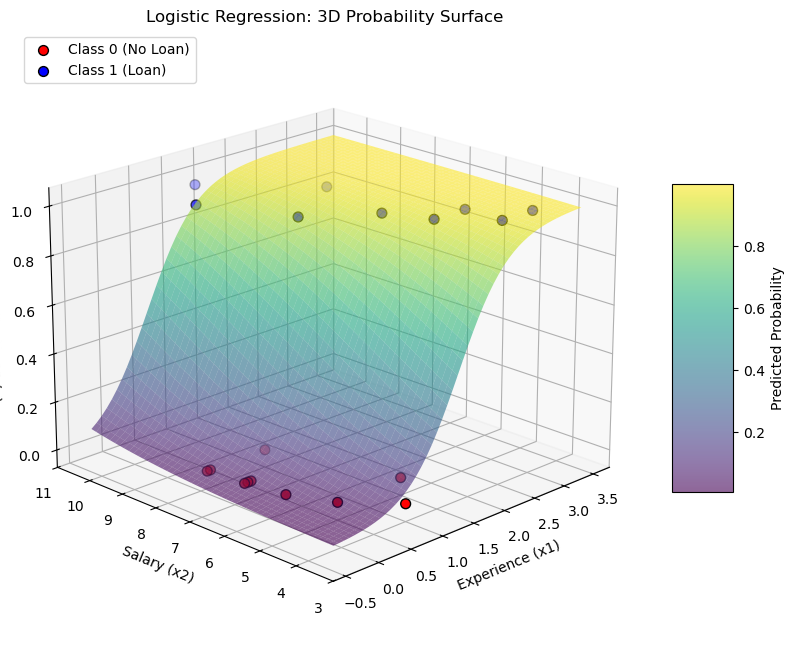

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_surface(x, y, w0, w1, w2):
    """
    Plots the 3D sigmoid surface and the actual data points.
    """
    # Convert lists to numpy arrays for easier mathematical slicing
    x_np = np.array(x)
    y_np = np.array(y)
    
    # Extract feature 1 (Experience) and feature 2 (Salary)
    x1 = x_np[:, 0]
    x2 = x_np[:, 1]
    
    # Create a new figure and a 3D axis
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Plot the actual data points
    # Points where y=0 (No Loan)
    ax.scatter(x1[y_np == 0], x2[y_np == 0], y_np[y_np == 0], 
               color='red', label='Class 0 (No Loan)', s=50, edgecolors='k')
    # Points where y=1 (Loan)
    ax.scatter(x1[y_np == 1], x2[y_np == 1], y_np[y_np == 1], 
               color='blue', label='Class 1 (Loan)', s=50, edgecolors='k')

    # 2. Create the Sigmoid Surface (Hyperplane)
    # Generate a grid of values covering the min and max of your data
    x1_grid = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 50)
    x2_grid = np.linspace(x2.min() - 0.5, x2.max() + 0.5, 50)
    xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
    
    # Calculate the linear combination (Z) for every point on the grid
    Z = w1 * xx1 + w2 * xx2 + w0
    
    # Apply the sigmoid function to get the probability (P) surface
    # We use np.clip to prevent overflow warnings in np.exp
    Z_clipped = np.clip(Z, -500, 500)
    P = 1 / (1 + np.exp(-Z_clipped))
    
    # Plot the surface
    surface = ax.plot_surface(xx1, xx2, P, alpha=0.6, cmap='viridis', 
                              linewidth=0, antialiased=True)
    
    # 3. Formatting the plot
    ax.set_title("Logistic Regression: 3D Probability Surface")
    ax.set_xlabel("Experience (x1)")
    ax.set_ylabel("Salary (x2)")
    ax.set_zlabel("Probability / Loan (y)")
    
    # Add a color bar for the surface probabilities
    fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Probability')
    ax.legend(loc='upper left')
    
    # Set the initial viewing angle
    ax.view_init(elev=20, azim=-135)
    
    plt.show()

plot_3d_surface(x, y, wo, w1, w2)

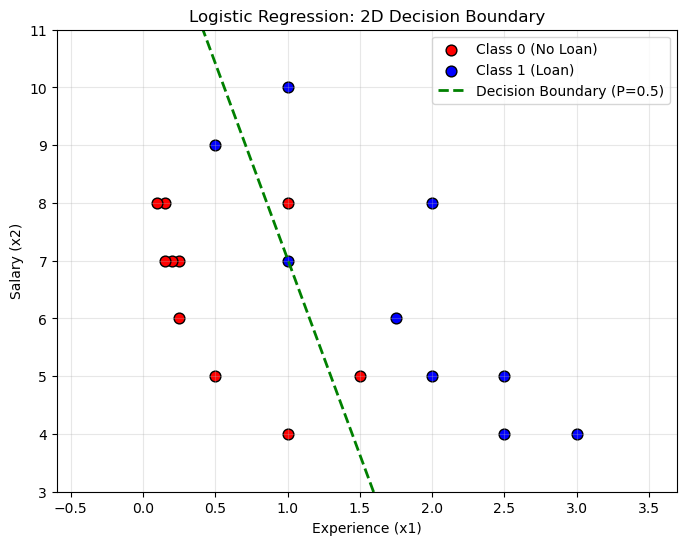

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_2d_decision_boundary(x, y, w0, w1, w2):
    """
    Plots the 2D scatter of data points and the logistic regression decision line.
    """
    # Convert lists to numpy arrays
    x_np = np.array(x)
    y_np = np.array(y)
    
    # Extract feature 1 (Experience) and feature 2 (Salary)
    x1 = x_np[:, 0]
    x2 = x_np[:, 1]
    
    plt.figure(figsize=(8, 6))
    
    # 1. Plot the actual data points
    plt.scatter(x1[y_np == 0], x2[y_np == 0], color='red', label='Class 0 (No Loan)', edgecolors='k', s=60)
    plt.scatter(x1[y_np == 1], x2[y_np == 1], color='blue', label='Class 1 (Loan)', edgecolors='k', s=60)
    
    # 2. Calculate the Decision Boundary Line
    # Get the minimum and maximum values of the x-axis to draw the line across the whole plot
    x1_min, x1_max = x1.min() - 0.5, x1.max() + 0.5
    
    # Apply the mathematical formula we derived above
    # x2 = (-w1 * x1 - w0) / w2
    x2_min = (-w1 * x1_min - w0) / w2
    x2_max = (-w1 * x1_max - w0) / w2
    
    # 3. Plot the line connecting those two points
    plt.plot([x1_min, x1_max], [x2_min, x2_max], color='green', linestyle='--', linewidth=2, label='Decision Boundary (P=0.5)')
    
    # 4. Formatting the plot
    # Set the y-axis limits to roughly match our data so the line doesn't distort the view
    plt.ylim(x2.min() - 1, x2.max() + 1) 
    
    plt.title("Logistic Regression: 2D Decision Boundary")
    plt.xlabel("Experience (x1)")
    plt.ylabel("Salary (x2)")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.show()

plot_2d_decision_boundary(x, y, wo, w1, w2)